# YOLO Inference Example
3개 클래스(DOOR, JOG, MEMORY)에 대한 객체 탐지 추론

In [70]:
from ultralytics import YOLO
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# 모델 경로
MODEL_PATH = '/data/th/KETI/Grounded-SAM-2/trained_models/yolo_20251121_1623582/yolo_20251121_054253/weights/best.pt'

# 모델 로드
model = YOLO(MODEL_PATH)

# 클래스 정보
classes = {0: 'DOOR', 1: 'JOG', 2: 'MEMORY'}

print(f"모델 로드 완료: {MODEL_PATH}")
print(f"클래스: {classes}")

FileNotFoundError: [Errno 2] No such file or directory: '/data/th/KETI/Grounded-SAM-2/trained_models/yolo_20251121_1623582/yolo_20251121_054253/weights/best.pt'

In [ ]:
# 추론 함수
def predict_and_visualize(image_path, conf=0.5):
    """
    이미지에서 객체를 탐지하고 시각화
    
    Args:
        image_path: 이미지 파일 경로
        conf: 신뢰도 임계값 (0.0 ~ 1.0)
    """
    # 이미지 로드
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"이미지를 로드할 수 없습니다: {image_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 추론 수행
    results = model.predict(image_path, conf=conf, verbose=False)
    result = results[0]
    
    # 결과 시각화
    annotated_frame = result.plot()
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # 탐지된 객체 정보 출력
    print(f"\n이미지: {Path(image_path).name}")
    print(f"탐지된 객체 수: {len(result.boxes)}")
    
    for idx, box in enumerate(result.boxes):
        class_id = int(box.cls[0].item())
        class_name = classes[class_id]
        confidence = box.conf[0].item()
        coords = box.xyxy[0].tolist()
        
        print(f"  {idx+1}. {class_name} (신뢰도: {confidence:.2%})")
        print(f"     위치: x1={coords[0]:.1f}, y1={coords[1]:.1f}, x2={coords[2]:.1f}, y2={coords[3]:.1f}")
    
    # 이미지 표시
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


이미지: 55_on.jpg
탐지된 객체 수: 3
  1. MEMORY (신뢰도: 95.95%)
     위치: x1=1107.6, y1=419.4, x2=1135.8, y2=449.1
  2. JOG (신뢰도: 95.86%)
     위치: x1=1178.0, y1=422.6, x2=1205.5, y2=452.9
  3. JOG (신뢰도: 22.44%)
     위치: x1=842.7, y1=139.2, x2=868.4, y2=165.7


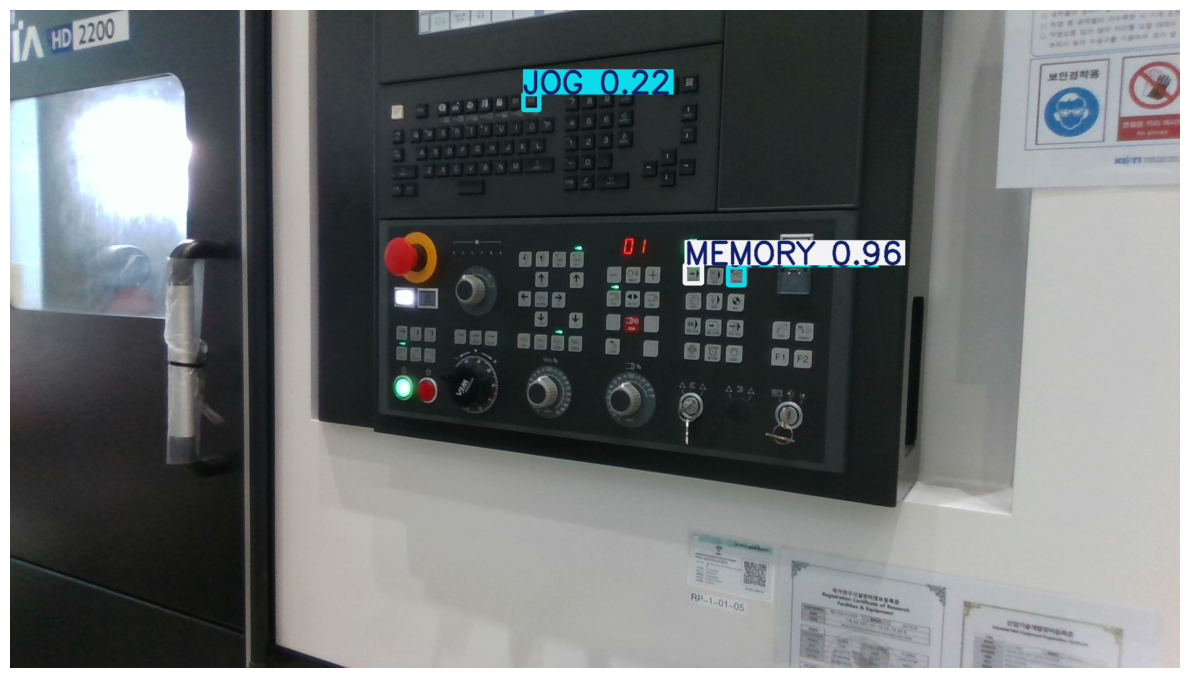

In [84]:
# 추론 실행
# 이미지 파일 경로를 지정하세요
image_path = './images/55_on.jpg'  # 추론할 이미지 경로를 지정

# 신뢰도 임계값 설정 (기본값: 0.5)
confidence_threshold = 0.1

predict_and_visualize(image_path, conf=confidence_threshold)